# System Capacity & Care Load Analytics for Unaccompanied Children

## Notebook 03: Exploratory Data Analysis & Derived Capacity Metrics

---

### Project Overview

This notebook builds the derived healthcare capacity metrics called for in
the project brief — total system load, net daily intake, care load growth
rate, and a backlog indicator — and then explores how they trend over time,
including daily/weekly/monthly patterns and a comparison of the early vs.
late portions of the timeline.


In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams["figure.facecolor"] = "white"
%matplotlib inline

In [2]:
# Load the validated dataset from Notebook 02
df = pd.read_csv("../data/Processed/UAC_validated.csv", parse_dates=["Date"])
df.head()

,Date,CBP_Intake,CBP_Custody,CBP_Transferred,HHS_Care,HHS_Discharged
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0
1,2023-01-22,32.0,49.0,39.0,7122.0,227.0
2,2023-01-23,32.0,50.0,39.0,7280.0,181.0
3,2023-01-24,47.0,42.0,47.0,7433.0,175.0
4,2023-01-25,20.0,22.0,41.0,7538.0,180.0


---
# A. Derived Healthcare Capacity Metrics

In [3]:
# Total System Load = CBP Custody + HHS Care
df["TotalSystemLoad"] = df["CBP_Custody"] + df["HHS_Care"]

# Net Daily Intake = Transfers into HHS − Discharges from HHS
df["NetDailyIntake"] = df["CBP_Transferred"] - df["HHS_Discharged"]

# Care Load Growth Rate = day-over-day percentage change in total system load
df["CareLoadGrowthRate"] = df["TotalSystemLoad"].pct_change() * 100
df["CareLoadGrowthRate"] = df["CareLoadGrowthRate"].replace([np.inf, -np.inf], np.nan)

df[["Date", "TotalSystemLoad", "NetDailyIntake", "CareLoadGrowthRate"]].head()

,Date,TotalSystemLoad,NetDailyIntake,CareLoadGrowthRate
0,2023-01-12,6619.0,-402.0,NaN
1,2023-01-22,7171.0,-188.0,8.339628
2,2023-01-23,7330.0,-142.0,2.217264
3,2023-01-24,7475.0,-128.0,1.978172
4,2023-01-25,7560.0,-139.0,1.137124


In [4]:
# Backlog Indicator: sustained positive net intake over a trailing window
# (14 reports) signals the system is accumulating backlog rather than
# relieving it
df["Backlog14"] = df["NetDailyIntake"].rolling(14, min_periods=1).sum()
df["BacklogLabel"] = np.where(df["Backlog14"] > 0, "Backlog Building", "Backlog Relieving")

df["BacklogLabel"].value_counts()

BacklogLabel
Backlog Relieving    466
Backlog Building     254
Name: count, dtype: int64

### Observation

Across the full period, reporting days split between those where the system
is actively accumulating backlog (net intake into HHS care is outpacing
discharges over the trailing window) and those where it is being relieved.
This split is the foundation for the strain/relief classification used in
Notebook 04's KPIs.

---
# B. Daily, Weekly & Monthly Trends

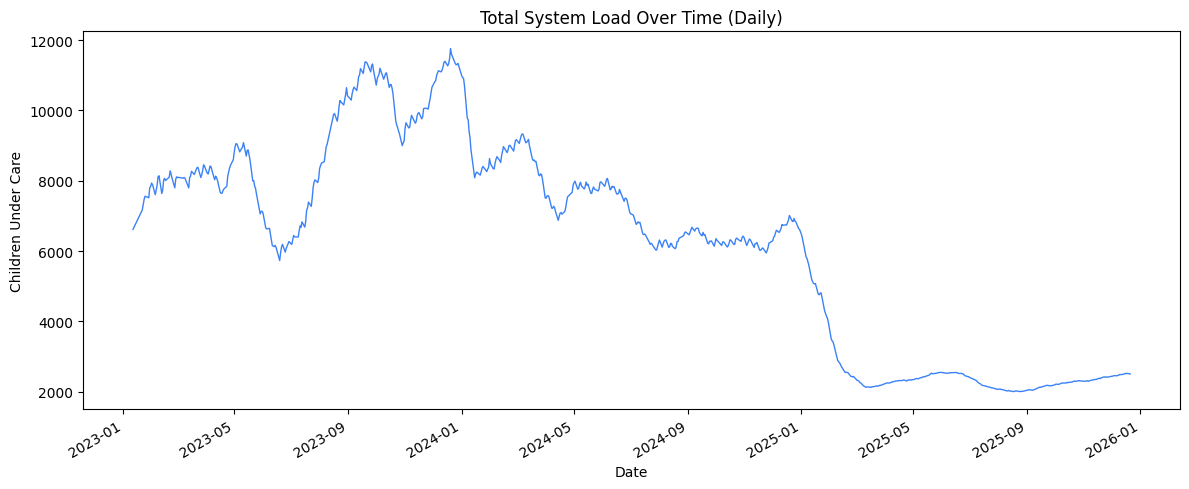

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["Date"], df["TotalSystemLoad"], color="#3b82f6", linewidth=1)
ax.set_title("Total System Load Over Time (Daily)")
ax.set_ylabel("Children Under Care")
ax.set_xlabel("Date")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

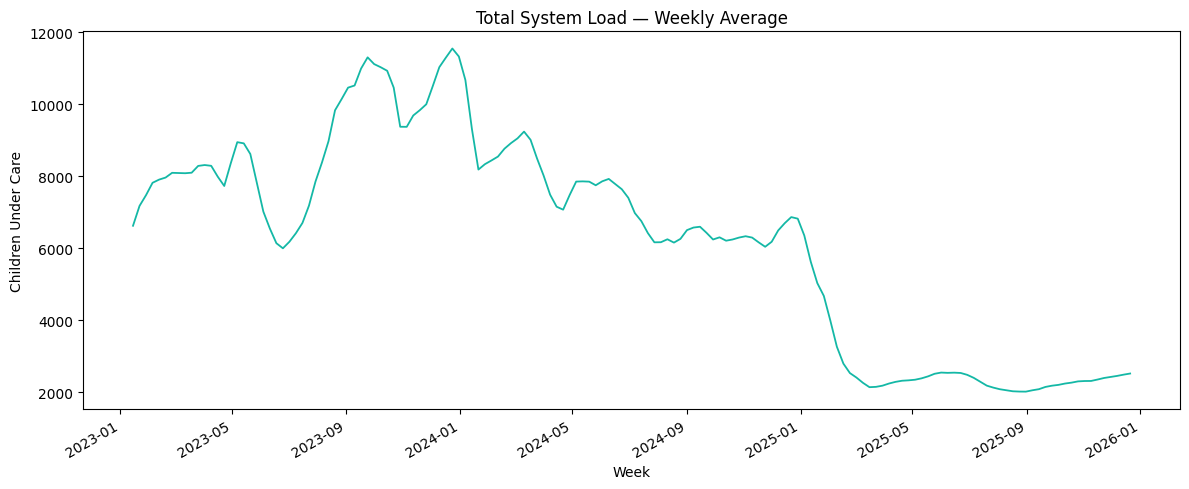

In [6]:
# Weekly average
weekly = df.set_index("Date")["TotalSystemLoad"].resample("W").mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(weekly.index, weekly.values, color="#14b8a6", linewidth=1.3)
ax.set_title("Total System Load — Weekly Average")
ax.set_ylabel("Children Under Care")
ax.set_xlabel("Week")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

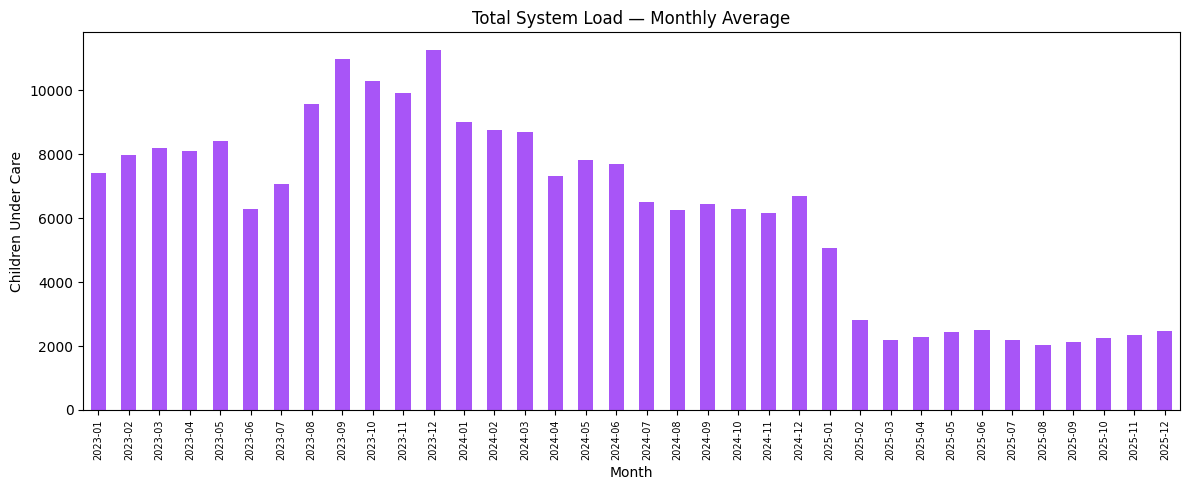

In [7]:
# Monthly average
df["MonthPeriod"] = df["Date"].dt.to_period("M")
monthly = df.groupby("MonthPeriod")["TotalSystemLoad"].mean()

fig, ax = plt.subplots(figsize=(12, 5))
monthly.plot(kind="bar", ax=ax, color="#a855f7")
ax.set_title("Total System Load — Monthly Average")
ax.set_ylabel("Children Under Care")
ax.set_xlabel("Month")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

---
# C. Sustained High-Load Periods

In [8]:
# Flag reporting days in the top decile of total system load
high_load_cutoff = df["TotalSystemLoad"].quantile(0.90)
df["HighLoadDay"] = df["TotalSystemLoad"] >= high_load_cutoff

print(f"High-load cutoff (90th percentile): {high_load_cutoff:,.0f} children")
print(f"High-load days: {df['HighLoadDay'].sum():,} ({df['HighLoadDay'].mean()*100:.1f}% of reporting days)")

High-load cutoff (90th percentile): 9,921 children
High-load days: 72 (10.0% of reporting days)


In [9]:
# Group consecutive high-load days into sustained windows
df["HighLoadGroup"] = (df["HighLoadDay"] != df["HighLoadDay"].shift()).cumsum()
sustained_windows = (
    df[df["HighLoadDay"]]
    .groupby("HighLoadGroup")
    .agg(start=("Date", "min"), end=("Date", "max"), reports=("Date", "size"))
    .reset_index(drop=True)
    .sort_values("reports", ascending=False)
)
sustained_windows.head(10)

,start,end,reports
0,2023-08-22,2023-10-19,41
2,2023-11-21,2024-01-04,30
1,2023-11-16,2023-11-16,1


### Observation

The table above lists the longest sustained runs of high-load reporting
days, sorted by duration. These windows are the operational periods worth
reviewing first for staffing and shelter-capacity post-mortems.

---
# D. Early vs. Late Timeline Comparison

In [10]:
midpoint = df["Date"].min() + (df["Date"].max() - df["Date"].min()) / 2
early = df[df["Date"] < midpoint]
late = df[df["Date"] >= midpoint]

comparison = pd.DataFrame({
    "Early Period": [early["TotalSystemLoad"].mean(), early["NetDailyIntake"].mean(), early["CBP_Custody"].mean(), early["HHS_Care"].mean()],
    "Late Period": [late["TotalSystemLoad"].mean(), late["NetDailyIntake"].mean(), late["CBP_Custody"].mean(), late["HHS_Care"].mean()],
}, index=["Avg. Total System Load", "Avg. Net Daily Intake", "Avg. CBP Custody", "Avg. HHS Care"])

comparison.round(1)

,Early Period,Late Period
Avg. Total System Load,8619.6,3872.3
Avg. Net Daily Intake,-88.6,-1.4
Avg. CBP Custody,239.4,104.4
Avg. HHS Care,8380.3,3767.9


### Observation

Comparing the first and second halves of the timeline shows how the balance
between CBP custody and HHS care has shifted, and whether the system has
been net accumulating or net relieving load on average across each half.

---
# E. Rolling Averages & Variability

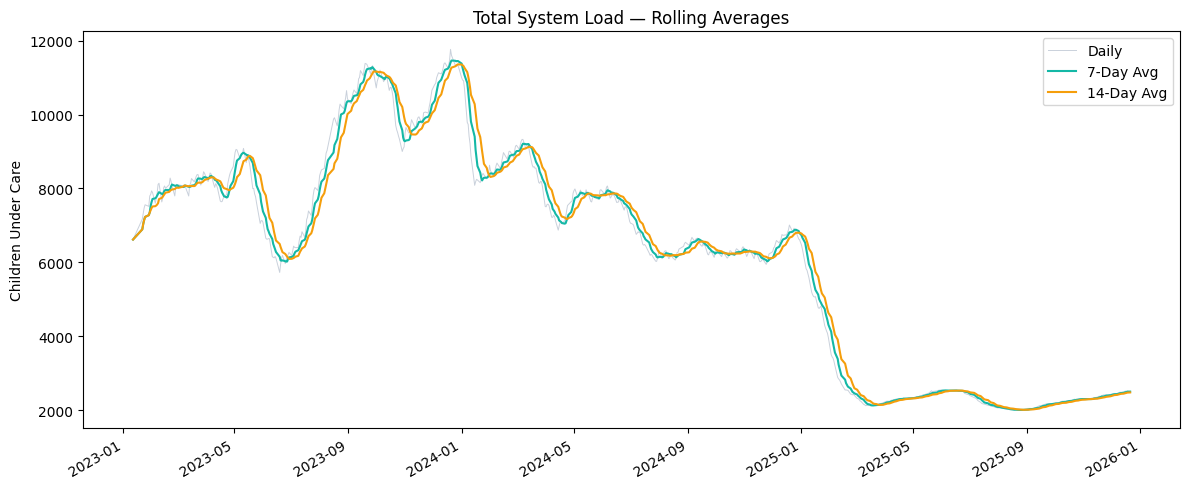

In [11]:
df["Rolling7_Load"] = df["TotalSystemLoad"].rolling(7, min_periods=1).mean()
df["Rolling14_Load"] = df["TotalSystemLoad"].rolling(14, min_periods=1).mean()
df["RollingStd7"] = df["TotalSystemLoad"].rolling(7, min_periods=2).std()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["Date"], df["TotalSystemLoad"], color="#94a3b8", linewidth=0.7, alpha=0.5, label="Daily")
ax.plot(df["Date"], df["Rolling7_Load"], color="#14b8a6", linewidth=1.5, label="7-Day Avg")
ax.plot(df["Date"], df["Rolling14_Load"], color="#f59e0b", linewidth=1.5, label="14-Day Avg")
ax.set_title("Total System Load — Rolling Averages")
ax.set_ylabel("Children Under Care")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

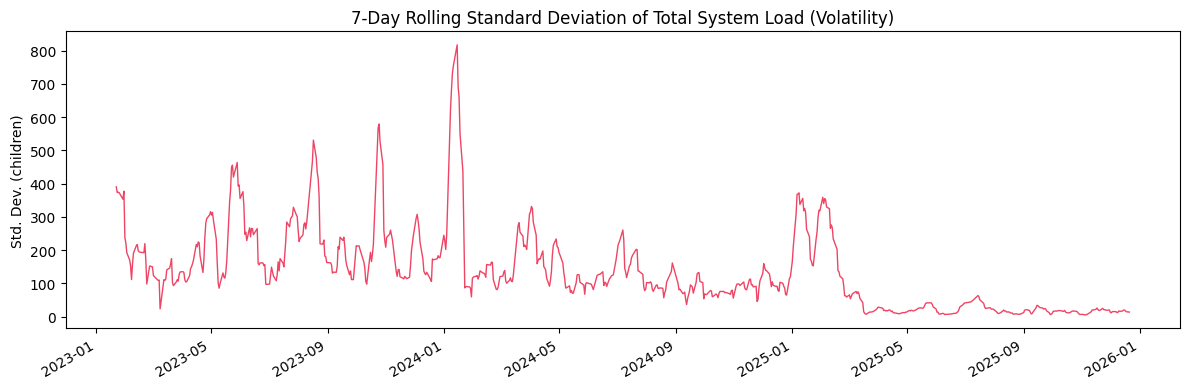

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["Date"], df["RollingStd7"], color="#ef4565", linewidth=1)
ax.set_title("7-Day Rolling Standard Deviation of Total System Load (Volatility)")
ax.set_ylabel("Std. Dev. (children)")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Observation

Spikes in the rolling standard deviation tend to precede or coincide with
the sustained high-load windows identified above — this makes 7-day
volatility a useful leading indicator, which is formalized as the Care Load
Volatility Index in Notebook 04.

---
# Saving the Enriched Dataset

In [13]:
df.to_csv("../data/Processed/UAC_enriched.csv", index=False)
print("Saved enriched dataset to ../data/Processed/UAC_enriched.csv")
df.columns.tolist()

Saved enriched dataset to ../data/Processed/UAC_enriched.csv


['Date',
 'CBP_Intake',
 'CBP_Custody',
 'CBP_Transferred',
 'HHS_Care',
 'HHS_Discharged',
 'TotalSystemLoad',
 'NetDailyIntake',
 'CareLoadGrowthRate',
 'Backlog14',
 'BacklogLabel',
 'MonthPeriod',
 'HighLoadDay',
 'HighLoadGroup',
 'Rolling7_Load',
 'Rolling14_Load',
 'RollingStd7']

---
# Conclusion

The exploratory analysis and derived-metric construction were completed
successfully:

### Key Findings

- Total System Load, Net Daily Intake, Care Load Growth Rate, and a 14-report
  Backlog Indicator were computed as specified in the project brief.
- Daily, weekly, and monthly views all show a clear cyclical structure with
  periods of sustained high load.
- The top-decile high-load days cluster into identifiable sustained windows
  rather than being scattered randomly across the timeline.
- Comparing the early and late halves of the timeline shows a measurable
  shift in the balance between CBP custody and HHS care.
- 7-day rolling volatility rises ahead of sustained high-load windows,
  making it a useful early-warning signal, carried forward as a formal KPI
  in **Notebook 04**.
